In [1]:
import torch
from torch import Tensor, nn
from typing import Dict, Optional
from math import ceil
import numpy as np
from torch.autograd import Function
import os
from torch.autograd.function import Function
from functools import partial
import math
import triton
from copy import deepcopy
import triton.language as tl
from triton.tools.tensor_descriptor import TensorDescriptor

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [2]:
os.environ["TRITON_PRINT_AUTOTUNING"] = "1"

In [3]:
from triton_kernels.utils import get_device
from triton_kernels.nn.gated_mlp.gated_mlp import NaiveGatedMLP, FusedGatedMLP
from triton_kernels.nn.gated_mlp.gated_mlp import (
    ACT_FWD,
)

In [4]:

# def eager_fwd(
#     x: Tensor,
#     WT_up: Tensor,
#     b_up: Optional[Tensor],
#     WT_gp: Tensor,
#     b_gp: Optional[Tensor],
#     # act_fn: str,
#     # dropout_p: float,
# ) -> Tensor:

#     act_fn = "silu"

#     up = x @ WT_up.T
#     if b_up is not None:
#         up += b_up

#     gated = x @ WT_gp.T
#     if b_gp is not None:
#         gated += b_gp

#     gated = ACT_FWD[act_fn](gated)
#     out = gated * up
#     # x = nn.functional.dropout(x, dropout_p, training)
#     return out


# def eager_bwd(x, W_up, W_gp, grad_output):
#     act_fn = "silu"

#     ### compute fwd pass quantities
#     a = x @ W_up.T
#     b = x @ W_gp.T
#     c = ACT_FWD[act_fn](b)
#     sigma = torch.sigmoid(b)

#     ### some quantities for bwd computation
#     act_prime = sigma * (1 + b * (1 - sigma))
#     grad_output_a_act_prime = (grad_output * a) * act_prime
#     grad_output_c = grad_output * c

#     ### dx
#     dx_1 = grad_output_c @ W_up
#     dx_2 = grad_output_a_act_prime @ W_gp
#     dx = dx_1 + dx_2

#     ### dW_up
#     dW_up = grad_output_c.T @ x

#     ### dW_gp
#     dW_gp = grad_output_a_act_prime.T @ x

#     return dx, dW_up, dW_gp


# class GatedMLPFunction(Function):
#     @staticmethod
#     def forward(
#         ctx,
#         x: Tensor,
#         W_up: Tensor,
#         b_up: Tensor,
#         W_gp: Tensor,
#         b_gp: Tensor,
#         # act_fn: str,
#         # dropout_p: float,
#     ) -> Tensor:
#         # hidden_states = eager_fwd(x, W_up, b_up, W_gp, b_gp)
#         hidden_states = eager_fwd(
#             x=x,
#             WT_up=W_up,
#             b_up=None,
#             WT_gp=W_gp,
#             b_gp=None,
#             # act_fn="silu",
#             # dropout_p=0.0,
#         )

#         ctx.save_for_backward(x, W_up, W_gp)

#         return hidden_states

#     @staticmethod
#     def backward(ctx, grad_output):
#         x, W_up, W_gp = ctx.saved_tensors

#         # import pydevd
#         # pydevd.settrace(suspend=False, trace_only_current_thread=True)
#         # print(f"{x.shape=}")
#         # print(f"{W_up.shape=}")
#         # print(f"{W_gp.shape=}")
#         # print(f"{grad_output.shape=}")

#         # dx, dW_up, dW_gp = eager_bwd(x, W_up, W_gp, grad_output)
#         dx, dW_up, dW_gp = eager_bwd(x, W_up, W_gp, grad_output)

#         return dx, dW_up, None, dW_gp, None


# class NaiveGatedMLP(nn.Module):
#     def __init__(
#         self,
#         hidden_size: int = 256,
#         intermediate_size: int = 512,
#         bias: bool = True,
#         hidden_act: str = "silu",
#         dropout_p: float = 0.0,
#     ):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.intermediate_size = intermediate_size
#         self.gate_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
#         self.up_proj = nn.Linear(self.hidden_size, self.intermediate_size, bias=bias)
#         self.down_proj = nn.Linear(self.intermediate_size, self.hidden_size, bias=bias)
#         self.act = ACT_FWD[hidden_act]
#         self.act_fn = hidden_act
#         self.dropout = nn.Dropout(dropout_p)

#     def forward(self, x: Tensor) -> Tensor:
#         # hidden_states = self.dropout(self.act(self.gate_proj(x)) * self.up_proj(x))
#         shapes = x.shape
#         if len(shapes) > 2:
#             x = x.view(-1, shapes[-1])
#         hidden_states = GatedMLPFunction.apply(
#             x,
#             self.up_proj.weight,
#             self.up_proj.bias,
#             self.gate_proj.weight,
#             self.gate_proj.bias,
#             # self.act_fn,
#             # self.dropout.p,
#         )
#         down_proj = self.down_proj(hidden_states)
#         return down_proj.view(shapes) if len(shapes) > 2 else down_proj

provider='torch', DTYPE=torch.float16, M=128, N=32, K=64
provider='triton', DTYPE=torch.float16, M=128, N=32, K=64

testing BLOCK_SIZE_M: 64, BLOCK_SIZE_N: 16, BLOCK_SIZE_K: 32, GROUP_SIZE_M: 2, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
_bench returned 0.006144000217318535

testing BLOCK_SIZE_M: 16, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 128, GROUP_SIZE_M: 8, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
_bench returned 0.006144000217318535

testing BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 32, BLOCK_SIZE_K: 64, GROUP_SIZE_M: 4, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
_bench returned 0.0071680000983178616

testing BLOCK_SIZE_M: 32, BLOCK_SIZE_N: 128, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 16, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
_bench returned 0.007424000184983015

testing BLOCK_SIZE_M: 128, BLOCK_SIZE_N: 64, BLOCK_SIZE_K: 16, GROUP_SIZE_M: 16, num_warps: 4, num_ctas: 1, num_stages: 3, maxnreg: None
_bench returned 0.010239999741315842

testing BLOC

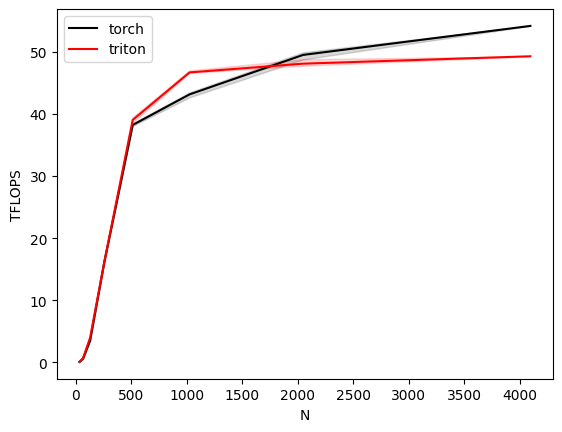

gated-mlp-performance:
        N       M       K      torch     triton
0    32.0    32.0    32.0   0.085333   0.098043
1    64.0    64.0    64.0   0.594581   0.670255
2   128.0   128.0   128.0   3.510857   3.985297
3   256.0   256.0   256.0  16.159561  16.159561
4   512.0   512.0   512.0  38.207224  39.019301
5  1024.0  1024.0  1024.0  43.122931  46.660985
6  2048.0  2048.0  2048.0  49.477136  48.068426
7  4096.0  4096.0  4096.0  54.140671  49.258732


In [5]:
providers = ["torch", "triton"]

available_colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple", "grey"]
colors = available_colors[:len(providers)]



configs = []
# for fp8_inputs in [True]:
configs.append(
    triton.testing.Benchmark(
        x_names=["N", "M", "K"],  # Argument names to use as an x-axis for the plot
        x_vals=[int(2 ** i) for i in np.arange(5, 13, 1)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
        line_vals=providers, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=providers, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
        styles=[(x, "-") for x, _ in zip(colors,providers)], # ("green", "-"), ("blue", "-")],
        ylabel="TFLOPS",  # Label name for the y-axis
        plot_name="gated-mlp-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))


def step(mlp, x):
    out = mlp(x)
    loss = out.sum()
    loss.backward()

MAP_MODULE = {
    "torch" : NaiveGatedMLP, 
    "triton" : FusedGatedMLP,
}

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):

    M *= 4
    K *= 2
    
    DTYPE = torch.float16
    DEVICE = get_device()
    kwargs = {"device": DEVICE, "dtype": DTYPE}

    gmlp_kwargs = {
        "hidden_size" : K, 
        "intermediate_size" : N,
        "dropout_p" : 0.0, 
        "bias" : False,
    }
    gmlp = MAP_MODULE[provider](**gmlp_kwargs).to(DEVICE).to(DTYPE)

    print(f"{provider=}, {DTYPE=}, {M=}, {N=}, {K=}")
    
    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    x.requires_grad = True

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(
        lambda: step(gmlp, x), 
        quantiles=quantiles
    ) 
    perf = lambda ms: 9 * 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

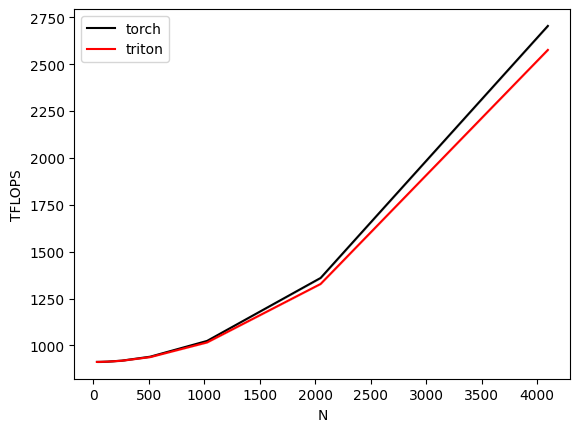

gated-mlp-performance:
        N       M       K        torch       triton
0    32.0    32.0    32.0   912.352539   912.352539
1    64.0    64.0    64.0   912.688477   912.657227
2   128.0   128.0   128.0   914.000977   913.875977
3   256.0   256.0   256.0   919.250977   918.750977
4   512.0   512.0   512.0   940.250977   938.250977
5  1024.0  1024.0  1024.0  1024.250977  1016.250977
6  2048.0  2048.0  2048.0  1360.250977  1328.250977
7  4096.0  4096.0  4096.0  2704.250977  2576.250977


In [6]:


@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider):

    M *= 4
    K *= 2
    
    DTYPE = torch.float16
    DEVICE = get_device()

    gmlp_kwargs = {
        "hidden_size" : K, 
        "intermediate_size" : N,
        "dropout_p" : 0.0, 
        "bias" : False,
    }
    
    # Initialize model
    gmlp = MAP_MODULE[provider](**gmlp_kwargs).to(DEVICE).to(DTYPE)
    
    # Initialize input
    x = torch.randn((M, K), device=DEVICE, dtype=DTYPE)
    x.requires_grad = True

    # 1. Warmup
    # Run the function once to allocate gradients and internal buffers
    # that persist (like parameter gradients).
    # We want to measure the memory cost of the OPERATION, usually excluding model weights
    # or including them depending on your goal. 
    # Here, we reset stats AFTER model load to measure activation + temp buffer overhead.
    # step(gmlp, x)
    torch.cuda.synchronize()

    # 2. Measure Memory
    torch.cuda.reset_peak_memory_stats(DEVICE)
    torch.cuda.empty_cache() # Optional: clear fragmentation

    # Run the step
    step(gmlp, x)
    
    # Capture Peak
    max_memory_bytes = torch.cuda.max_memory_allocated(DEVICE)
    
    # Convert to MB
    max_memory_mb = max_memory_bytes / 1024 / 1024
    
    # Triton bench expects (y, y_min, y_max). 
    # Since memory is deterministic (mostly), min/max are the same.
    return max_memory_mb, max_memory_mb, max_memory_mb


benchmark.run(show_plots=True, print_data=True)
